In [79]:
import sys

import pandas as pd
import numpy as np

from from_root import from_root

sys.path.insert(0, str(from_root("src")))

from read_and_write_docs import read_rds

In [ ]:
base_location = "/Volumes/BCross/av_datasets_experiments/concat_ngram_masking_logprobs_gc/_results_v2"
base_location = "/Users/user/Documents/uni_work_offline/av_datasets_experiments/concat_ngram_masking_logprobs_gc/_results_v2"

plot_location = f"{base_location}/graphs"

file_loc = f"{base_location}/performance_summary_by_token_calibrated_raw.rds"

df = read_rds(file_loc)

# Load in the test metadata to get problem counts
# metadata = read_rds("/Volumes/BCross/datasets/author_verification/test/metadata.rds")
metadata = read_rds("/Users/user/Documents/uni_work_offline/datasets/author_verification/test/metadata.rds")

# Just keep the main scoring column as most consistently accurate
scored_df = df[
    (df['scoring_col'].isin(['unknown_sum_log_probs']))
]

In [84]:
df.head(5)

,corpus,scoring_model,max_context_tokens,min_token_size,scoring_col,Cllr,Cllr_min,EER,Mean TRUE LLR10,Mean FALSE LLR10,...,FALSE cases,AUC,Balanced Accuracy,Precision,Recall,F1,TP,FN,FP,TN
0,ACL,gpt2,0.0,1.0,unknown_sum_log_probs,0.931329,0.881771,38.152444,0.049301,-0.128412,...,140,0.658316,0.628571,0.663636,0.521429,0.584000,73,67,37,103
1,ACL,gpt2,0.0,2.0,unknown_sum_log_probs,0.908683,0.858972,36.812657,0.101970,-0.152188,...,140,0.674745,0.653571,0.697248,0.542857,0.610442,76,64,33,107
2,ACL,gpt2,0.0,3.0,unknown_sum_log_probs,0.849643,0.803378,33.206436,0.355252,-0.210358,...,136,0.724265,0.683344,0.742857,0.565217,0.641975,78,60,27,109
3,ACL,gpt2,0.0,4.0,unknown_sum_log_probs,0.796090,0.733908,27.337398,0.786288,-0.202327,...,111,0.783571,0.758069,0.833333,0.669291,0.742358,85,42,17,94
4,ACL,gpt2,0.0,5.0,unknown_sum_log_probs,0.838276,0.743907,28.205128,0.964106,-0.193493,...,46,0.781991,0.758152,0.916667,0.625000,0.743243,55,33,5,41


## Initial Filters

In [77]:
# Just keep the main scoring column as most consistently accurate
scored_df = df[
    (df['scoring_col'].isin(['unknown_sum_log_probs']))
].copy()

# We only want to keep the corpora in the LambdaG paper
corpus_dict = {
    "Enron Cleaned": "CEnron",
    "Wiki": "CWiki",
    "StackExchange": "CStack",
    "ACL": "CACL",
    "Perverted Justice": "CPJ",
    "The Apricity": "CApric",
    "TripAdvisor": "CTrip",
    "Yelp": "CYelp",
    "IMDB": "CIMDB",
    "Koppel's Blogs": "CBlog",
    "Amazon": "CAmazon",
    "All-the-news": "CAllNews"
}

filtered_df = scored_df[
    scored_df['corpus'].isin(corpus_dict)
    & (scored_df['min_token_size'] <= 8)
].copy()

# Replace each corpus name with its corresponding abbreviated value
filtered_df['corpus'] = filtered_df['corpus'].map(corpus_dict)

filtered_metadata = metadata[
    metadata['corpus'].isin(corpus_dict)
].copy()

In [85]:
problem_counts = (
    filtered_metadata
    .groupby("corpus")
    .size()
    .reset_index(name="total_problems")
    .sort_values("corpus")
    .reset_index(drop=True)
)

problem_counts

,corpus,total_problems
0,ACL,280
1,All-the-news,2662
2,Amazon,2400
3,Enron Cleaned,90
4,IMDB,1600
5,Koppel's Blogs,1800
6,Perverted Justice,312
7,StackExchange,228
8,The Apricity,340
9,TripAdvisor,480


In [86]:
complete_problems = filtered_df[['corpus', 'max_context_tokens', 'min_token_size', 'TRUE cases', 'FALSE cases']].copy()

complete_problems['completed_cases'] = complete_problems['TRUE cases'] + complete_problems['FALSE cases']

complete_problems = complete_problems.merge(
    problem_counts,
    on="corpus",
    how="left"
)

complete_problems["percentage_complete"] = (
    complete_problems["completed_cases"] / complete_problems["total_problems"]
) * 100

complete_problems["percentage_true"] = (
    complete_problems["TRUE cases"] / complete_problems["completed_cases"]
) * 100

complete_problems = complete_problems[complete_problems['max_context_tokens'] == 10]

In [87]:
complete_problems

,corpus,max_context_tokens,min_token_size,TRUE cases,FALSE cases,completed_cases,total_problems,percentage_complete,percentage_true
7,CACL,10.0,1.0,140,140,280,NaN,NaN,50.000000
8,CACL,10.0,2.0,140,140,280,NaN,NaN,50.000000
9,CACL,10.0,3.0,138,136,274,NaN,NaN,50.364964
10,CACL,10.0,4.0,127,111,238,NaN,NaN,53.361345
11,CACL,10.0,5.0,88,46,134,NaN,NaN,65.671642
...,...,...,...,...,...,...,...,...,...
871,CYelp,10.0,2.0,240,240,480,NaN,NaN,50.000000
872,CYelp,10.0,3.0,204,155,359,NaN,NaN,56.824513
873,CYelp,10.0,4.0,82,35,117,NaN,NaN,70.085470
874,CYelp,10.0,5.0,19,3,22,NaN,NaN,86.363636


<positron-console-cell-90>:29: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
<positron-console-cell-90>:29: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.


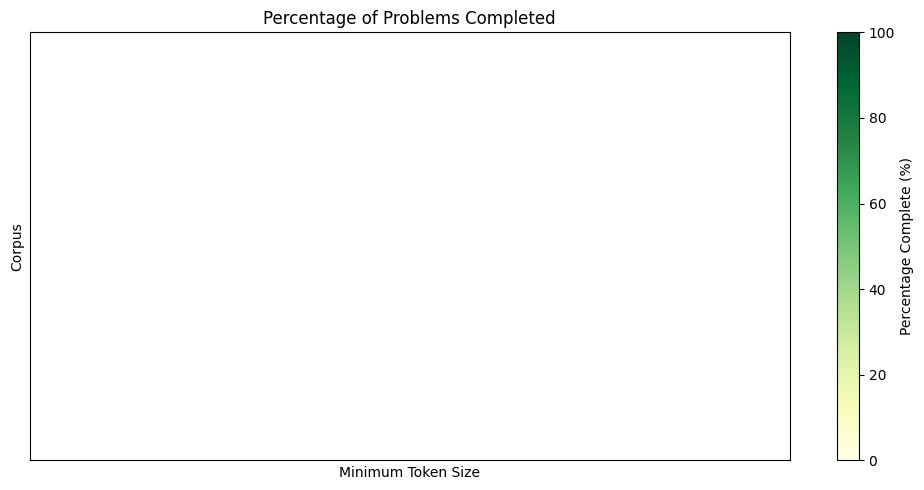

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# Create matrix:
# rows = corpus
# columns = min_token_size
# values = percentage_complete
heatmap_df = complete_problems.pivot_table(
    index="corpus",
    columns="min_token_size",
    values="percentage_complete",
    aggfunc="first"
)

# Sort axes
heatmap_df = heatmap_df.sort_index()
heatmap_df = heatmap_df.reindex(
    sorted(heatmap_df.columns),
    axis=1
)

fig, ax = plt.subplots(
    figsize=(
        max(10, len(heatmap_df.columns) * 0.8),
        max(5, len(heatmap_df.index) * 0.7)
    )
)

image = ax.imshow(
    heatmap_df,
    aspect="auto",
    cmap="YlGn",
    vmin=0,
    vmax=100
)

# Axis labels
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(
    heatmap_df.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_xlabel("Minimum Token Size")
ax.set_ylabel("Corpus")
ax.set_title("Percentage of Problems Completed")

# Add percentage values inside cells
for row_idx, corpus in enumerate(heatmap_df.index):
    for col_idx, min_token_size in enumerate(heatmap_df.columns):

        value = heatmap_df.loc[corpus, min_token_size]

        if pd.notna(value):
            ax.text(
                col_idx,
                row_idx,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

# Percentage colour bar
colour_bar = fig.colorbar(image, ax=ax)
colour_bar.set_label("Percentage Complete (%)")

plt.tight_layout()

plt.savefig(
    f"{plot_location}/percentage_complete_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

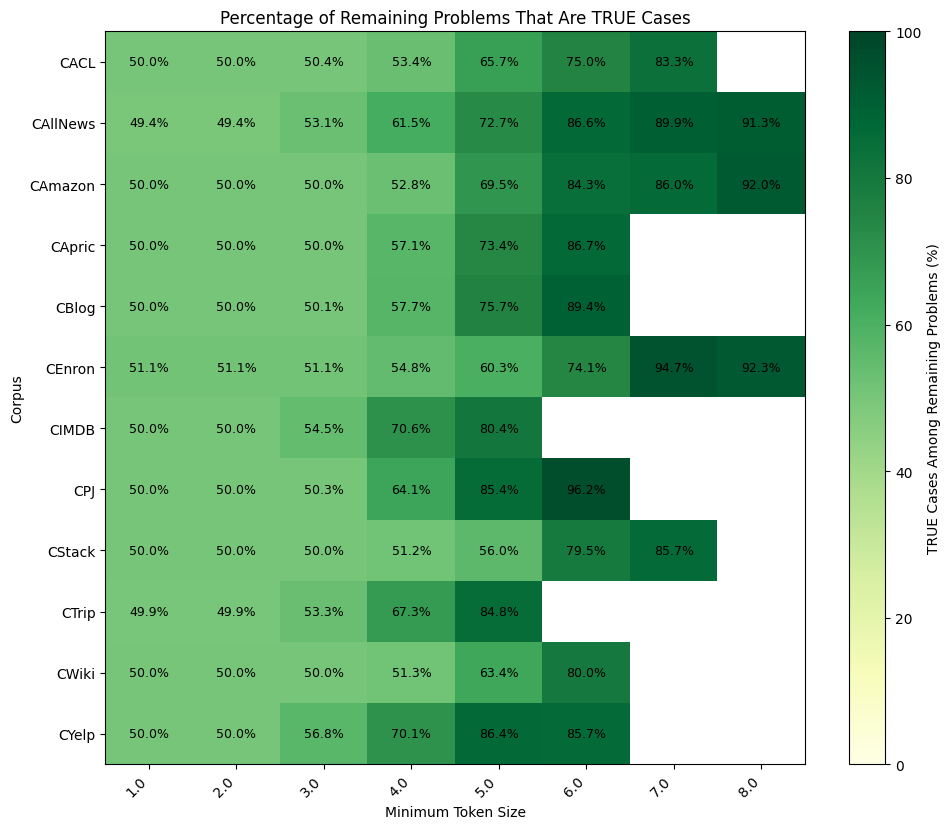

In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create heatmap matrix
heatmap_true_df = complete_problems.pivot_table(
    index="corpus",
    columns="min_token_size",
    values="percentage_true",
    aggfunc="first"
)

# Sort rows and columns
heatmap_true_df = heatmap_true_df.sort_index()
heatmap_true_df = heatmap_true_df.reindex(
    sorted(heatmap_true_df.columns),
    axis=1
)

fig, ax = plt.subplots(
    figsize=(
        max(10, len(heatmap_true_df.columns) * 0.8),
        max(5, len(heatmap_true_df.index) * 0.7)
    )
)

image = ax.imshow(
    heatmap_true_df,
    aspect="auto",
    cmap="YlGn",
    vmin=0,
    vmax=100
)

# Axis labels
ax.set_xticks(range(len(heatmap_true_df.columns)))
ax.set_xticklabels(
    heatmap_true_df.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_true_df.index)))
ax.set_yticklabels(heatmap_true_df.index)

ax.set_xlabel("Minimum Token Size")
ax.set_ylabel("Corpus")
ax.set_title("Percentage of Remaining Problems That Are TRUE Cases")

# Add percentage values inside cells
for row_idx, corpus in enumerate(heatmap_true_df.index):
    for col_idx, min_token_size in enumerate(heatmap_true_df.columns):

        value = heatmap_true_df.loc[corpus, min_token_size]

        if pd.notna(value):
            ax.text(
                col_idx,
                row_idx,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

# Percentage colour bar
colour_bar = fig.colorbar(image, ax=ax)
colour_bar.set_label("TRUE Cases Among Remaining Problems (%)")

plt.tight_layout()

plt.savefig(
    f"{plot_location}/percentage_true_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

In [93]:
filtered_df_3 = filtered_df[
    (filtered_df['min_token_size'] == 3)
].copy()

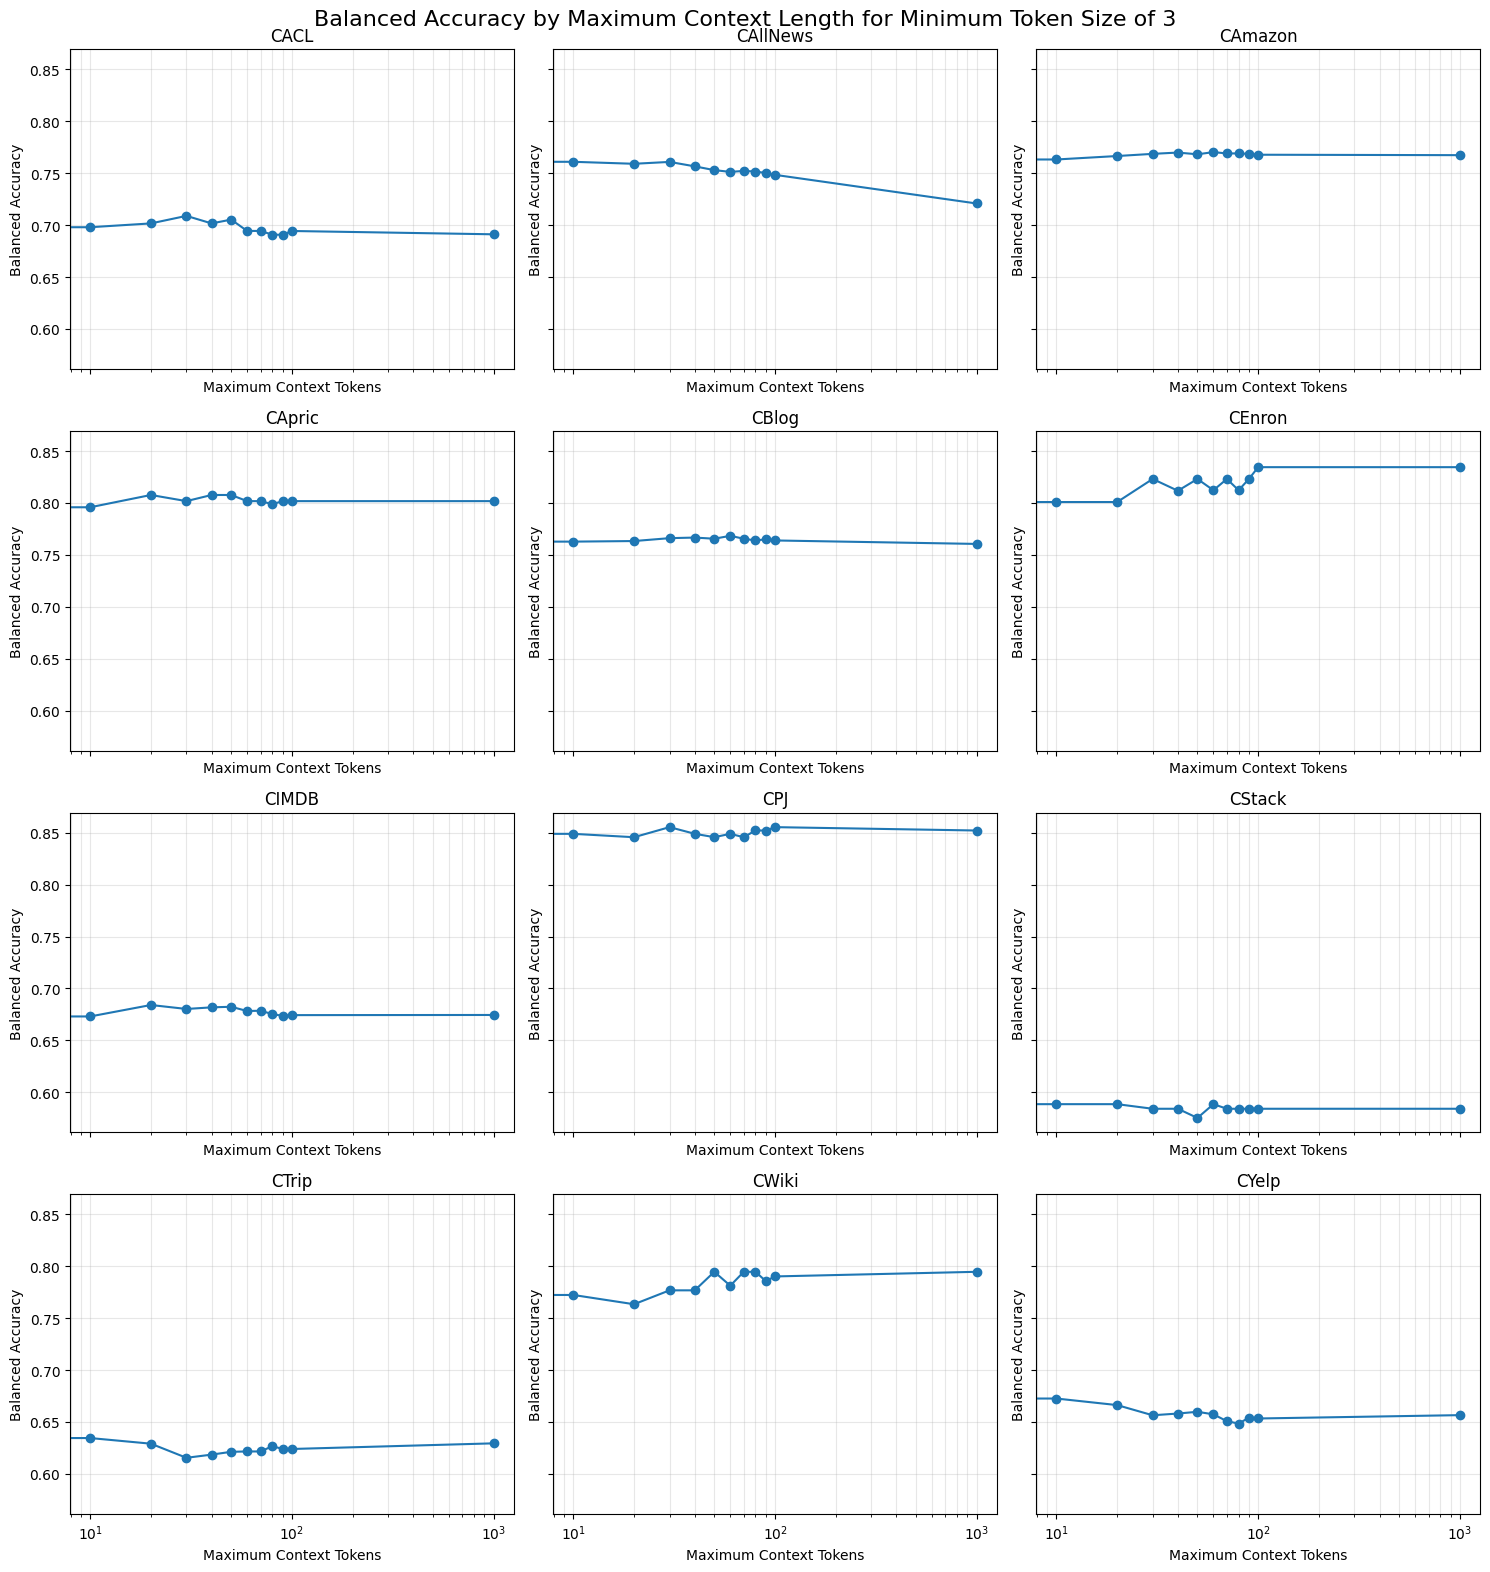

In [97]:
import matplotlib.pyplot as plt
import math

plot_df = filtered_df_3.sort_values(
    ["corpus", "max_context_tokens"]
)

corpora = plot_df["corpus"].dropna().unique()

n_cols = 3
n_rows = math.ceil(len(corpora) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False
)

axes = axes.flatten()

for ax, corpus in zip(axes, corpora):
    corpus_df = (
        plot_df[
            plot_df["corpus"] == corpus
        ]
        .sort_values("max_context_tokens")
    )

    ax.plot(
        corpus_df["max_context_tokens"],
        corpus_df["Balanced Accuracy"],
        marker="o"
    )

    ax.set_xscale("log")
    ax.set_title(corpus)
    ax.set_xlabel("Maximum Context Tokens")
    ax.set_ylabel("Balanced Accuracy")
    ax.grid(alpha=0.3, which="both")

# Remove unused facets
for ax in axes[len(corpora):]:
    ax.remove()

fig.suptitle(
    "Balanced Accuracy by Maximum Context Length for Minimum Token Size of 3",
    fontsize=16
)

fig.tight_layout()

plt.savefig(
    f"{plot_location}/accuracy_by_context_length_min3.pdf",
    bbox_inches="tight"
)
plt.show()